# Gasoil MM — Lead/Lag Analysis with Prices (as of date join)

Gasoil positioning from **two sources**:
- ICE Futures Europe (primary — the QS benchmark)
- CFTC/NYMEX (2 flat price contracts)

Codes from cot-ingest/docs/gasoil_cot_mapping.md.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Load Gasoil COT from ICE + CFTC

In [2]:
# --- ICE Europe: primary Gasoil contract ---
ICE_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cot-ingest/downloads/ice/ice_cot.csv'
ice = pd.read_csv(ICE_PATH, low_memory=False)

GS_COMBINED = 'ICE Gasoil Futures and Options - ICE Futures Europe'
GS_FUTURES  = 'ICE Gasoil Futures - ICE Futures Europe'

gs_comb = ice[ice['Market_and_Exchange_Names'] == GS_COMBINED].copy()
gs_fut  = ice[ice['Market_and_Exchange_Names'] == GS_FUTURES].copy()

for df_ice in [gs_comb, gs_fut]:
    df_ice['as_of_date'] = pd.to_datetime(df_ice['As_of_Date_Form_MM/DD/YYYY'])

combined_start = gs_comb['as_of_date'].min()
gs_early = gs_fut[gs_fut['as_of_date'] < combined_start]
gs_ice = pd.concat([gs_early, gs_comb], ignore_index=True)

ICE_COLS = {'Open_Interest_All': 'oi',
            'M_Money_Positions_Long_All': 'mm_long',
            'M_Money_Positions_Short_All': 'mm_short'}
for old, new in ICE_COLS.items():
    gs_ice[new] = pd.to_numeric(gs_ice[old], errors='coerce')
gs_ice = gs_ice[['as_of_date', 'oi', 'mm_long', 'mm_short']].copy()
gs_ice['source'] = 'ICE'

print(f'ICE Gasoil: {len(gs_ice)} rows, {gs_ice["as_of_date"].min().date()} -> {gs_ice["as_of_date"].max().date()}')


ICE Gasoil: 909 rows, 2011-01-04 -> 2026-03-24


In [3]:
# --- CFTC/NYMEX: Gasoil flat price contracts ---
CFTC_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'
cftc = pd.read_csv(CFTC_PATH, low_memory=False)

# Gasoil flat price codes (from cot-ingest/docs/gasoil_cot_mapping.md)
GASOIL_CFTC_CODES = [
    '02265V',  # GASOIL (ICE) SWAP (cash-settled, referencing ICE Gasoil)
    '022A46',  # GASOIL AVG PRICE OPTIONS
]

gs_cftc = cftc[cftc['cftc_contract_market_code'].isin(GASOIL_CFTC_CODES)].copy()
gs_cftc['as_of_date'] = pd.to_datetime(gs_cftc['report_date_as_yyyy_mm_dd'])
for c in ['open_interest_all', 'm_money_positions_long_all', 'm_money_positions_short_all']:
    gs_cftc[c] = pd.to_numeric(gs_cftc[c], errors='coerce')

gs_nymex = gs_cftc.groupby('as_of_date').agg(
    oi=('open_interest_all', 'sum'),
    mm_long=('m_money_positions_long_all', 'sum'),
    mm_short=('m_money_positions_short_all', 'sum'),
).reset_index()
gs_nymex['source'] = 'CFTC'

print(f'CFTC Gasoil: {len(gs_nymex)} rows, {gs_nymex["as_of_date"].min().date()} -> {gs_nymex["as_of_date"].max().date()}')


CFTC Gasoil: 65 rows, 2009-10-20 -> 2012-09-04


In [4]:
# --- Combine ICE + CFTC ---
combined = pd.concat([gs_ice, gs_nymex], ignore_index=True)
gasoil = combined.groupby('as_of_date').agg(
    oi=('oi', 'sum'), mm_long=('mm_long', 'sum'), mm_short=('mm_short', 'sum'),
).reset_index()

gasoil['mm_net'] = gasoil['mm_long'] - gasoil['mm_short']
gasoil['mm_net_oi'] = gasoil['mm_net'] / gasoil['oi'] * 100
days_ahead = (4 - gasoil['as_of_date'].dt.dayofweek) % 7
gasoil['release_date'] = gasoil['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
gasoil.sort_values('as_of_date', inplace=True)
gasoil.reset_index(drop=True, inplace=True)

print(f'Combined Gasoil: {len(gasoil)} rows')
print(f'Range: {gasoil["as_of_date"].min().date()} -> {gasoil["as_of_date"].max().date()}')


Combined Gasoil: 850 rows
Range: 2009-10-20 -> 2026-03-24


## 2. Load prices and join

In [5]:
prices = pd.read_csv('../../../../cache/preprocessed_data/gasoil_prices_panel.csv',
                      usecols=['tradeDate', 'F1_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)

prices_renamed = prices.rename(columns={'tradeDate': 'as_of_date'})
df = gasoil.merge(prices_renamed, on='as_of_date', how='inner')
df.sort_values('as_of_date', inplace=True)
df.reset_index(drop=True, inplace=True)
df['mm_net_chg']    = df['mm_net'].diff()
df['mm_net_oi_chg'] = df['mm_net_oi'].diff()
df['price_ret']     = df['F1_RolledPrice'].pct_change() * 100
df.dropna(subset=['mm_net_chg', 'price_ret'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Joined rows: {len(df)}')
print(f'Range: {df["as_of_date"].min().date()} -> {df["as_of_date"].max().date()}')


Joined rows: 838
Range: 2010-02-09 -> 2026-03-24


## 3. Contemporaneous correlation

In [6]:
rho, p = sp_stats.spearmanr(df['mm_net_chg'], df['price_ret'])
rho_oi, p_oi = sp_stats.spearmanr(df['mm_net_oi_chg'], df['price_ret'])
print('Contemporaneous (same week):')
print(f'  MM net change vs price return:    rho = {rho:+.3f}  (p = {p:.1e})')
print(f'  MM net/OI change vs price return: rho = {rho_oi:+.3f}  (p = {p_oi:.1e})')


Contemporaneous (same week):
  MM net change vs price return:    rho = -0.139  (p = 5.2e-05)
  MM net/OI change vs price return: rho = -0.127  (p = 2.4e-04)


## 4. Cross-correlation function (Tuesday-Tuesday)

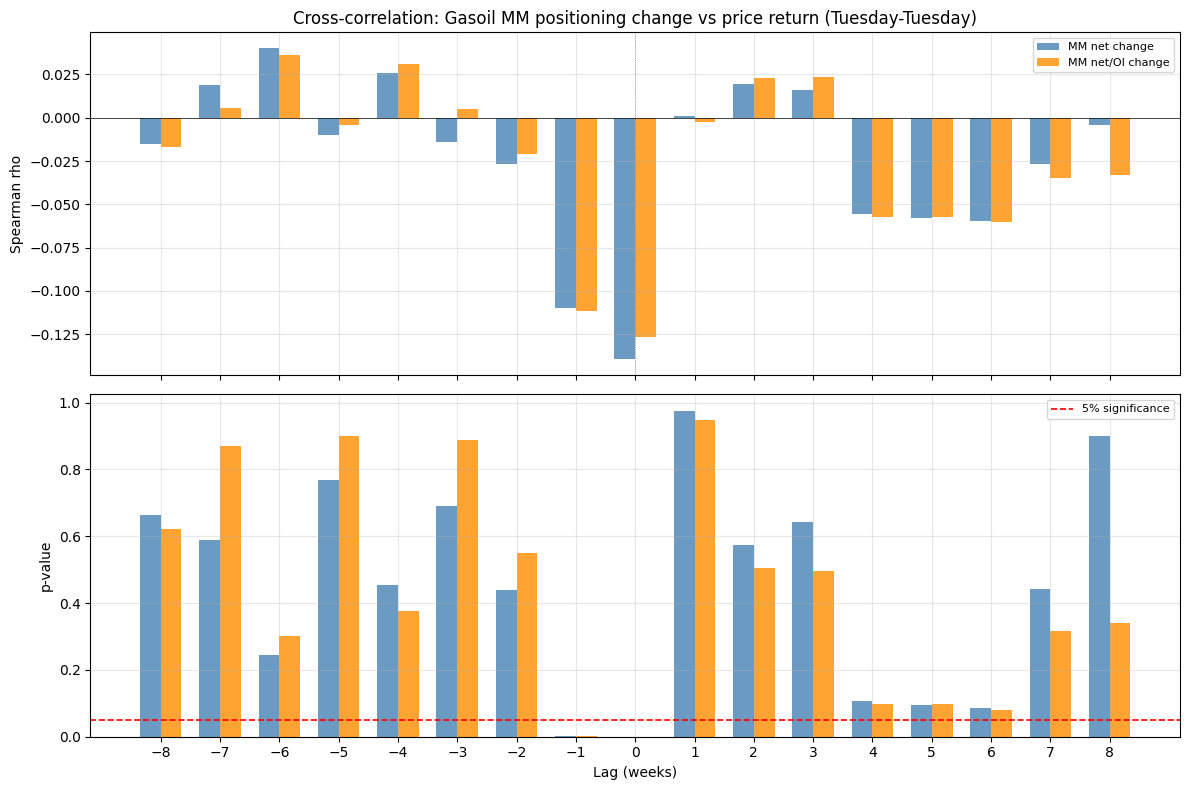

 Lag   rho (raw)       p-val    rho (OI)       p-val
-------------------------------------------------------
  -8     -0.015       6.6e-01     -0.017       6.2e-01
  -7     +0.019       5.9e-01     +0.006       8.7e-01
  -6     +0.040       2.5e-01     +0.036       3.0e-01
  -5     -0.010       7.7e-01     -0.004       9.0e-01
  -4     +0.026       4.6e-01     +0.031       3.8e-01
  -3     -0.014       6.9e-01     +0.005       8.9e-01
  -2     -0.027       4.4e-01     -0.021       5.5e-01
  -1     -0.110 *     1.4e-03     -0.112 *     1.2e-03
   0     -0.139 *     5.2e-05     -0.127 *     2.4e-04
   1     +0.001       9.8e-01     -0.002       9.5e-01
   2     +0.019       5.7e-01     +0.023       5.1e-01
   3     +0.016       6.4e-01     +0.024       5.0e-01
   4     -0.056       1.1e-01     -0.057       9.8e-02
   5     -0.058       9.5e-02     -0.057       9.9e-02
   6     -0.060       8.5e-02     -0.060       8.1e-02
   7     -0.027       4.4e-01     -0.035       3.2e-01
   8     -0

In [7]:
MAX_LAG = 8
def compute_ccf(x, y, max_lag):
    lags = range(-max_lag, max_lag + 1)
    rhos, pvals = [], []
    for k in lags:
        if k >= 0:
            rho, p = sp_stats.spearmanr(x[:len(x)-k], y[k:])
        else:
            rho, p = sp_stats.spearmanr(x[-k:], y[:len(y)+k])
        rhos.append(rho)
        pvals.append(p)
    return list(lags), rhos, pvals

net_vals = df['mm_net_chg'].values
oi_vals = df['mm_net_oi_chg'].values
price_vals = df['price_ret'].values
lags, rhos_raw, pvals_raw = compute_ccf(net_vals, price_vals, MAX_LAG)
_, rhos_oi, pvals_oi = compute_ccf(oi_vals, price_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
bar_width = 0.35
x_pos = np.array(lags)
ax = axes[0]
ax.bar(x_pos - bar_width/2, rhos_raw, bar_width, color='steelblue', alpha=0.8, label='MM net change')
ax.bar(x_pos + bar_width/2, rhos_oi, bar_width, color='darkorange', alpha=0.8, label='MM net/OI change')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('Cross-correlation: Gasoil MM positioning change vs price return (Tuesday-Tuesday)')
ax.legend(fontsize=8)
ax = axes[1]
ax.bar(x_pos - bar_width/2, pvals_raw, bar_width, color='steelblue', alpha=0.8)
ax.bar(x_pos + bar_width/2, pvals_oi, bar_width, color='darkorange', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% significance')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)')
ax.set_xticks(lags)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho (raw)":>10s}  {"p-val":>10s}  {"rho (OI)":>10s}  {"p-val":>10s}')
print('-' * 55)
for k, rr, pr, ro, po in zip(lags, rhos_raw, pvals_raw, rhos_oi, pvals_oi):
    sig_r = '*' if pr < 0.05 else ' '
    sig_o = '*' if po < 0.05 else ' '
    print(f'{k:>4d}  {rr:>+9.3f} {sig_r}  {pr:>10.1e}  {ro:>+9.3f} {sig_o}  {po:>10.1e}')


## 5. 2-year blocks

In [8]:
df['year'] = df['as_of_date'].dt.year
blocks_2y = [
    ('2011-2012', (2011, 2012)), ('2013-2014', (2013, 2014)),
    ('2015-2016', (2015, 2016)), ('2017-2018', (2017, 2018)),
    ('2019-2020', (2019, 2020)), ('2021-2022', (2021, 2022)),
    ('2023-2025', (2023, 2025)),
]
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY: print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))
for label, (y_start, y_end) in blocks_2y + [('Full sample', (2011, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()


       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2011-2012   104  -0.044  -0.202  -0.193  +0.018  -0.006
   2013-2014   104  +0.138  -0.283  -0.438  +0.055  +0.286
   2015-2016   104  -0.149  -0.344  -0.539  -0.062  +0.003
   2017-2018   104  -0.093  -0.438  -0.544  -0.001  +0.019
   2019-2020   104  -0.175  -0.262  -0.604  -0.126  -0.051
   2021-2022   104  -0.035  +0.151  +0.063  +0.103  -0.042
   2023-2025   156  -0.005  +0.309  +0.648  -0.011  -0.007
 Full sample   780  -0.026  -0.115  -0.152  -0.002  +0.019


## 5b. CCF by 5-year blocks

Is the lead/lag structure stable across different market regimes,
or is the full-sample CCF dominated by a particular period?

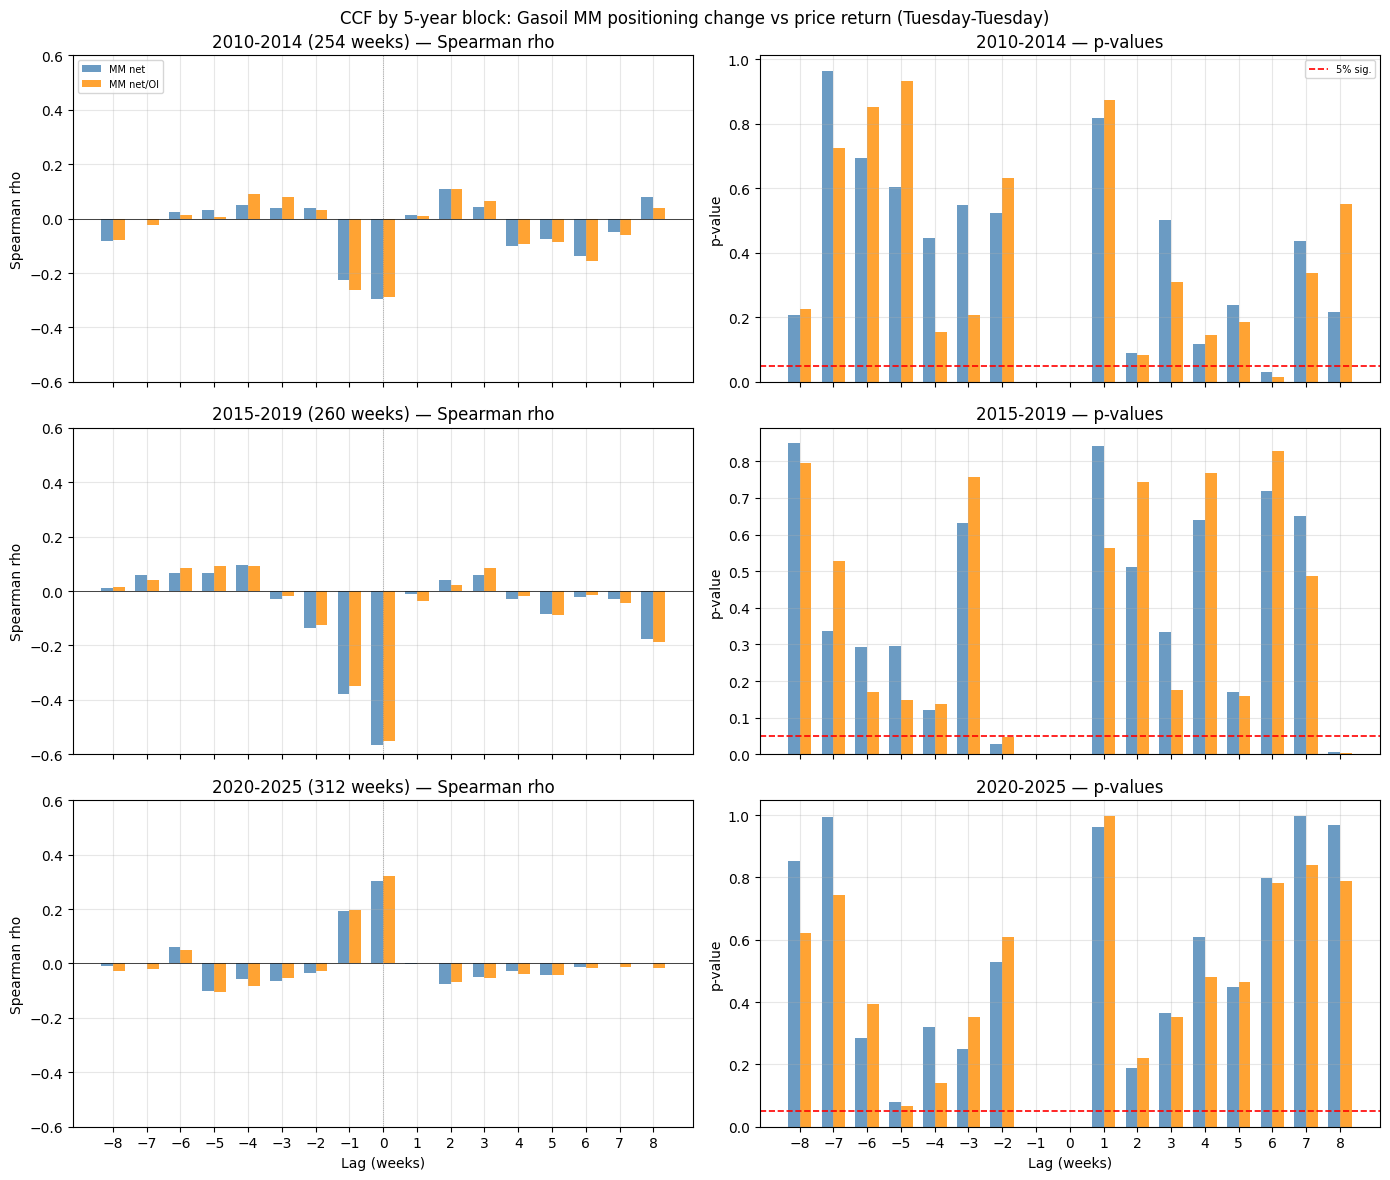

In [9]:
# Define 5-year blocks
blocks_5y = [
    ('2010-2014', (2010, 2014)),
    ('2015-2019', (2015, 2019)),
    ('2020-2025', (2020, 2025)),
]

fig, axes = plt.subplots(len(blocks_5y), 2, figsize=(14, 4 * len(blocks_5y)),
                         sharex=True)
bar_width = 0.35

for row, (label, (y_start, y_end)) in enumerate(blocks_5y):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    mm_oi_b = sub['mm_net_oi_chg'].values
    pr_b = sub['price_ret'].values

    lags_b, rhos_raw_b, pvals_raw_b = compute_ccf(mm_b, pr_b, MAX_LAG)
    _, rhos_oi_b, pvals_oi_b = compute_ccf(mm_oi_b, pr_b, MAX_LAG)
    x_pos = np.array(lags_b)

    ax = axes[row, 0]
    ax.bar(x_pos - bar_width/2, rhos_raw_b, bar_width,
           color='steelblue', alpha=0.8, label='MM net')
    ax.bar(x_pos + bar_width/2, rhos_oi_b, bar_width,
           color='darkorange', alpha=0.8, label='MM net/OI')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5, linestyle=':')
    ax.set_ylabel('Spearman rho')
    ax.set_title(f'{label} ({len(sub)} weeks) — Spearman rho')
    ax.set_ylim(-0.6, 0.6)
    if row == 0:
        ax.legend(fontsize=7, loc='upper left')

    ax = axes[row, 1]
    ax.bar(x_pos - bar_width/2, pvals_raw_b, bar_width,
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + bar_width/2, pvals_oi_b, bar_width,
           color='darkorange', alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
    ax.set_ylabel('p-value')
    ax.set_title(f'{label} — p-values')
    ax.set_xticks(lags_b)
    if row == 0:
        ax.legend(fontsize=7)

axes[-1, 0].set_xlabel('Lag (weeks)')
axes[-1, 1].set_xlabel('Lag (weeks)')
plt.suptitle('CCF by 5-year block: Gasoil MM positioning change vs price return (Tuesday-Tuesday)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_5y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()

       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2014   254  +0.040  -0.224  -0.294  +0.014  +0.107
   2015-2019   260  -0.136  -0.377  -0.565  -0.013  +0.041
   2020-2025   312  -0.036  +0.194  +0.302  -0.003  -0.075
 Full sample   826  -0.027  -0.110  -0.143  -0.001  +0.020


## 5c. CCF by 3-year blocks

Finer granularity to see how the lead/lag structure evolves.

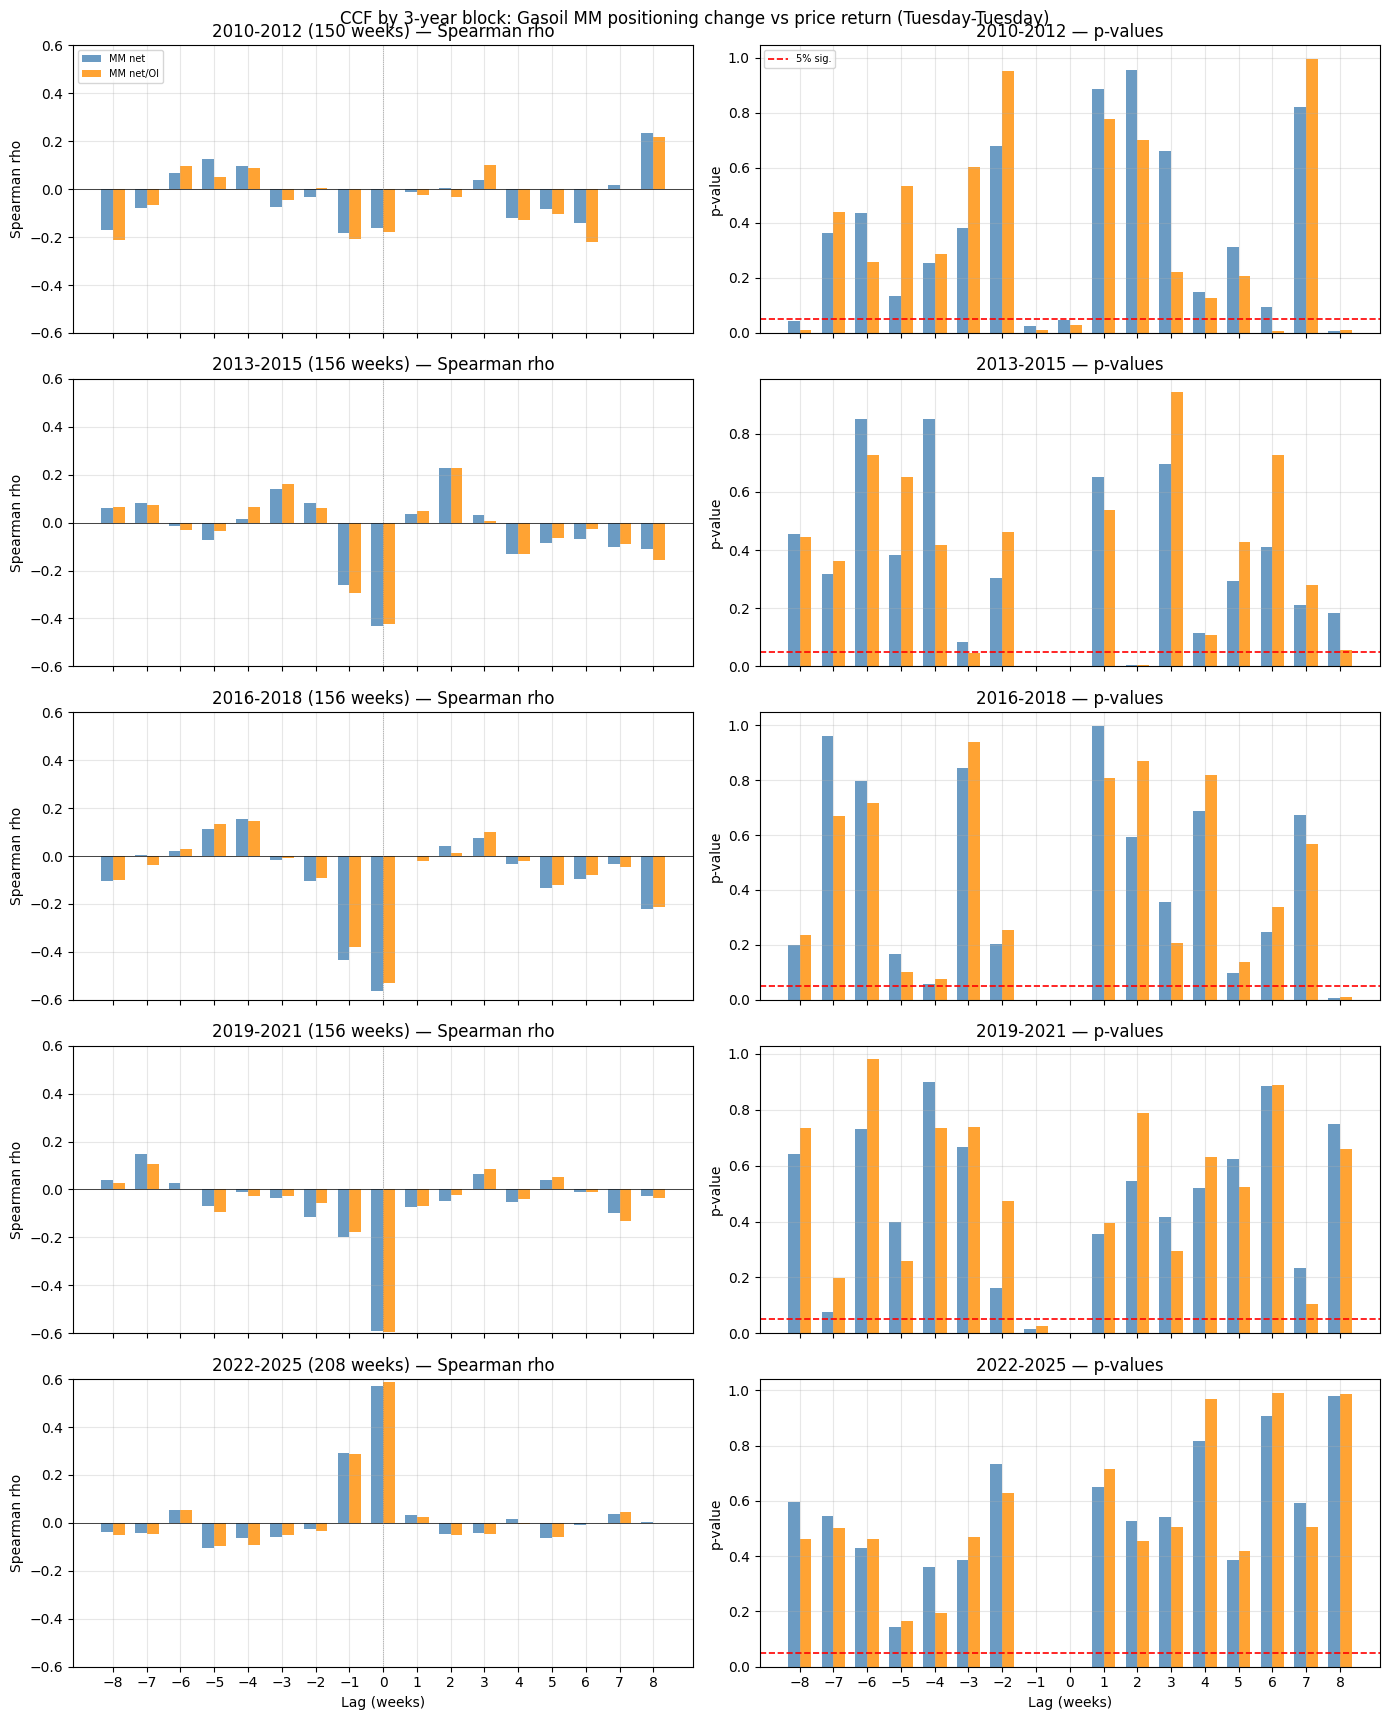

In [11]:
blocks_3y = [
    ('2010-2012', (2010, 2012)),
    ('2013-2015', (2013, 2015)),
    ('2016-2018', (2016, 2018)),
    ('2019-2021', (2019, 2021)),
    ('2022-2025', (2022, 2025)),
]

fig, axes = plt.subplots(len(blocks_3y), 2, figsize=(14, 3.5 * len(blocks_3y)),
                         sharex=True)
bar_width = 0.35

for row, (label, (y_start, y_end)) in enumerate(blocks_3y):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    mm_oi_b = sub['mm_net_oi_chg'].values
    pr_b = sub['price_ret'].values

    lags_b, rhos_raw_b, pvals_raw_b = compute_ccf(mm_b, pr_b, MAX_LAG)
    _, rhos_oi_b, pvals_oi_b = compute_ccf(mm_oi_b, pr_b, MAX_LAG)
    x_pos = np.array(lags_b)

    ax = axes[row, 0]
    ax.bar(x_pos - bar_width/2, rhos_raw_b, bar_width,
           color='steelblue', alpha=0.8, label='MM net')
    ax.bar(x_pos + bar_width/2, rhos_oi_b, bar_width,
           color='darkorange', alpha=0.8, label='MM net/OI')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5, linestyle=':')
    ax.set_ylabel('Spearman rho')
    ax.set_title(f'{label} ({len(sub)} weeks) — Spearman rho')
    ax.set_ylim(-0.6, 0.6)
    if row == 0:
        ax.legend(fontsize=7, loc='upper left')

    ax = axes[row, 1]
    ax.bar(x_pos - bar_width/2, pvals_raw_b, bar_width,
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + bar_width/2, pvals_oi_b, bar_width,
           color='darkorange', alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
    ax.set_ylabel('p-value')
    ax.set_title(f'{label} — p-values')
    ax.set_xticks(lags_b)
    if row == 0:
        ax.legend(fontsize=7)

axes[-1, 0].set_xlabel('Lag (weeks)')
axes[-1, 1].set_xlabel('Lag (weeks)')
plt.suptitle('CCF by 3-year block: Gasoil MM positioning change vs price return (Tuesday-Tuesday)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_3y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()

       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2012   150  -0.034  -0.181  -0.163  -0.012  +0.005
   2013-2015   156  +0.083  -0.260  -0.432  +0.037  +0.228
   2016-2018   156  -0.103  -0.434  -0.565  -0.000  +0.043
   2019-2021   156  -0.113  -0.196  -0.590  -0.075  -0.049
   2022-2025   208  -0.024  +0.290  +0.569  +0.032  -0.044
 Full sample   826  -0.027  -0.110  -0.143  -0.001  +0.020


## 6. Rolling stability of key lags

Are the lead/lag relationships stable over time? Compute the
lag -1, 0, +1 correlations on a rolling 104-week (2-year) window.

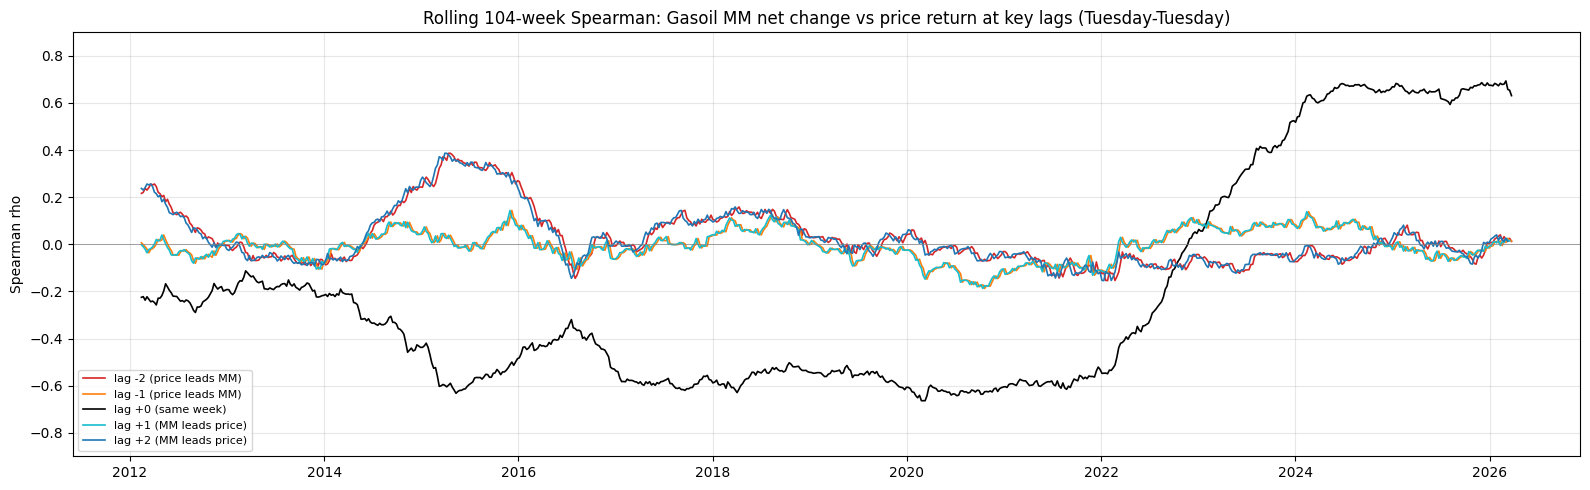

In [13]:
WINDOW = 104  # 2 years
KEY_LAGS = [-2, -1, 0, 1, 2]

mm_vals = df['mm_net_chg'].values
price_vals = df['price_ret'].values

rolling_results = {}
for k in KEY_LAGS:
    mm_s = pd.Series(mm_vals)
    pr_s = pd.Series(price_vals)
    if k >= 0:
        aligned_mm = mm_s.iloc[:len(mm_s)-k] if k > 0 else mm_s
        aligned_pr = pr_s.shift(-k).iloc[:len(pr_s)-k] if k > 0 else pr_s
    else:
        aligned_mm = mm_s.shift(-k)
        aligned_pr = pr_s

    rhos = []
    for i in range(len(aligned_mm)):
        if i < WINDOW:
            rhos.append(np.nan)
            continue
        m_win = aligned_mm.iloc[i-WINDOW:i].values
        p_win = aligned_pr.iloc[i-WINDOW:i].values
        mask = ~(np.isnan(m_win) | np.isnan(p_win))
        if mask.sum() < 20:
            rhos.append(np.nan)
        else:
            rhos.append(sp_stats.spearmanr(m_win[mask], p_win[mask]).statistic)
    rolling_results[k] = rhos[:len(df)]

fig, ax = plt.subplots(figsize=(16, 5))
lag_colors = {-2: 'tab:red', -1: 'tab:orange', 0: 'black', 1: 'tab:cyan', 2: 'tab:blue'}
for k in KEY_LAGS:
    label = f'lag {k:+d}' + (' (price leads MM)' if k < 0 else ' (MM leads price)' if k > 0 else ' (same week)')
    vals = rolling_results[k]
    ax.plot(df['as_of_date'].iloc[:len(vals)], vals,
            label=label, color=lag_colors[k], lw=1.2)

ax.axhline(0, color='grey', lw=0.5)
ax.set_title(f'Rolling {WINDOW}-week Spearman: Gasoil MM net change vs price return at key lags (Tuesday-Tuesday)')
ax.set_ylabel('Spearman rho')
ax.set_ylim(-0.9, 0.9)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Cumulative P&L

In [14]:
df['price_chg'] = df['F1_RolledPrice'].diff()
df['pnl'] = df['mm_net'].shift(1) * df['price_chg']
pnl = df.dropna(subset=['pnl']).copy()
pnl['cum_pnl'] = pnl['pnl'].cumsum()
ann = np.sqrt(52)
sr = pnl['pnl'].mean() / pnl['pnl'].std() * ann
total = pnl['pnl'].sum()
print(f'Gasoil MM Net Position P&L (raw contracts):')
print(f'  Cumulative P&L: ${total:>14,.0f}')
print(f'  Sharpe Ratio:   {sr:+.2f}')
print(f'  Weeks:          {len(pnl)}')


Gasoil MM Net Position P&L (raw contracts):
  Cumulative P&L: $   145,173,958
  Sharpe Ratio:   +0.33
  Weeks:          837


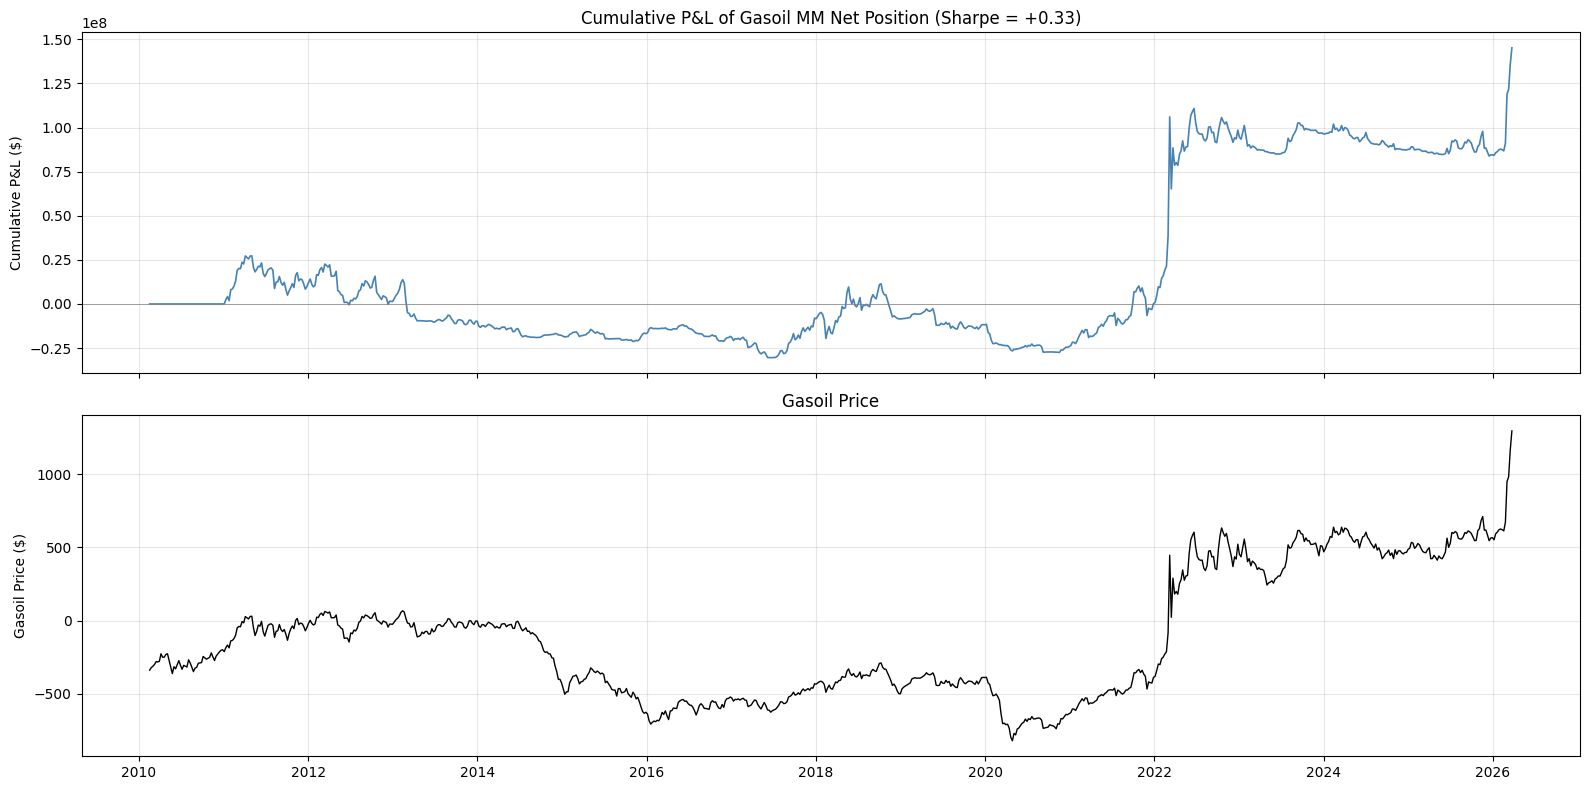

In [15]:
dt_pnl = pd.to_datetime(pnl['as_of_date'])
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
ax = axes[0]
ax.plot(dt_pnl, pnl['cum_pnl'], color='steelblue', lw=1.2)
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title(f'Cumulative P&L of Gasoil MM Net Position (Sharpe = {sr:+.2f})')
ax = axes[1]
ax.plot(dt_pnl, pnl['F1_RolledPrice'], color='black', lw=1)
ax.set_ylabel('Gasoil Price ($)')
ax.set_title('Gasoil Price')
plt.tight_layout()
plt.show()


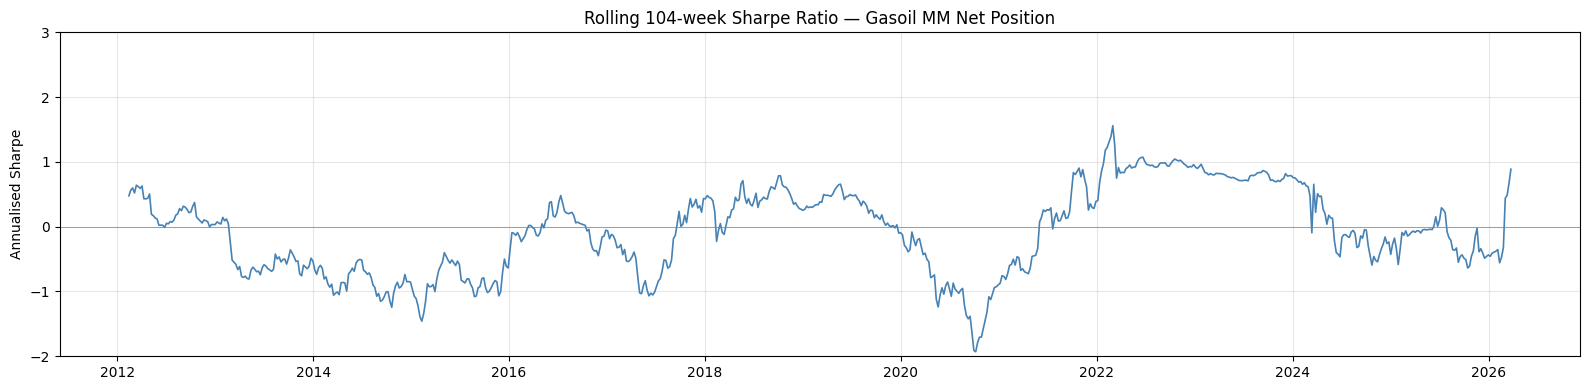

In [16]:
# Rolling 2-year Sharpe
ROLL_W = 104
ann = np.sqrt(52)
roll_sr = pnl['pnl'].rolling(ROLL_W).mean() / pnl['pnl'].rolling(ROLL_W).std() * ann

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(dt_pnl, roll_sr, color='steelblue', lw=1.2)
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Annualised Sharpe')
ax.set_title(f'Rolling {ROLL_W}-week Sharpe Ratio — Gasoil MM Net Position')
ax.set_ylim(-2, 3)
plt.tight_layout()
plt.show()